In [1]:
import numpy as np
import os
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import json
import concurrent.futures
from datasets import load_dataset
import scanpy as sc
from collections import Counter
import simfish


In [2]:
cell_num = 10000
cell_type_num = 5
gene_num = 50
patterns = 5
epithelial_features = ["EGFR", "DUOX1", "NKX2-1", "AGER", "RTKN2", "NAPSA", "PGC", "SFTA2",
                     "SFTPC", "SFTPD", "KRT14", "KRT15", "KRT5", "KRT6A", "S100A2",
                     "TP63", "KRT17", "AGR3", "C20orf85", "FOXJ1", "GCLM", "DMBT1",
                     "EPCAM", "KRT18", "MGST1", "MMP7", "FOXI1", "MUC5B", "SCGB1A1", 
                     "SCGB3A2", "WFDC2", "ATF3", "KRT8", "SOX9", "SPINK1", "GKN2",
                     "MMP10", "SOX2", "CDH26", "TP73", "CFTR", "HES1", "PKM", "SOX4",
                     "NUCB2", "RNASE1", "SAA2", "AKR1C1", "AKR1C2", "BPIFA1", "CEACAM5",
                     "ERN2", "FCGBP", "GSR", "LTF", "CCNA1", "ICAM1", "ITGB1"]
endothelial_features = ["APLN", "CA4", "HEY1", "BMPR2", "CD34", "EPAS1", "FCN3", 
                        "GNG11", "PECAM1", "APLNR", "COL15A1", "PLVAP", "ACKR1",
                        "POSTN", "CLDN5", "RAMP2", "ZEB1", "HAS1", "KDR", "CDKN2A"]
immune_features = ["PPARG", "BANK1", "CD19", "CD79A", "LTB", "MS4A1", "TNFRSF13C", 
                    "CD86", "GZMB", "HLA-DRA", "CCR7", "CXCR4", "PTPRC", "TCL1A", 
                    "CD69", "CD4", "CD8A", "CD8B", "CD2", "CD28", "CD3D", "CD3E", 
                    "CD3G", "FOXP3", "GZMK", "TRAC", "ITM2C", "CD27", "CCL5", "LCK", 
                    "FABP4", "MARCO", "MCEMP1", "SPP1", "FCN1", "S100A12", "S100A8", 
                    "S100A9", "CCL22", "ITGAM", "NFKB1",  "IFIT2", "FGFBP2", "GNLY", 
                    "KLRB1", "KLRC1", "NKG7", "LILRA4", "BCL2", "CD79B", "CXCR5", 
                    "CXCL9", "GPR183", "HLA-DQA1", "KLRG1", "BCL2L11", "CD52", 
                    "SLC1A3", "TNFRSF9", "CTLA4",  "IL2RA", "LAG3", "PDCD1", "PDIA6", 
                    "PIM2", "IL7R", "LEF1", "FASLG", "HAVCR2", "ISG20", "CPA3", 
                    "KIT", "TPSAB1", "C1QC", "CD68", "MS4A7", "AIF1", "CD14", 
                    "FCGR3A", "FCER1G", "SLC25A37", "CD247", "GZMA", "IRF7"]
mesenchymal_features = ["MFAP5", "PI16", "SFRP2", "ELN", "FAP", "AXL", "LGR6", 
                        "COL1A1", "COL1A2", "COL3A1", "DCN", "FN1", "HAS2", 
                        "LUM", "MEG3", "SPARCL1", "CTHRC1"]
cell_types = ["aCap", "Differentiating Ciliated", "B cells", "Alveolar FBs"]

#getting the genes that come from Epithelial, instead of 100% simulation, we mimic the real expression level of the cells from David dataset
hf_cache = "/scratch/project_465001027/Spatialformer/cache"
combined_dataset = load_dataset("TerminatorJ/xenium_25_lung_dataset_update4", cache_dir = hf_cache, num_proc = 8, split = "train")

#getting the expression profile
dc_dataset = combined_dataset.select_columns(['Annotations',"Transcript_Number", "Gene", "compound_key"])
#filter the certain cell types
dc_dataset_sub = dc_dataset.filter(lambda x: x["Annotations"] in cell_types, num_proc = 8)



Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/59 [00:00<?, ?it/s]

In [3]:
all_features = epithelial_features[:20] + endothelial_features[:20] + immune_features[:20] + mesenchymal_features[:20]

In [4]:
dc_dataset_sub

Dataset({
    features: ['Annotations', 'Transcript_Number', 'Gene', 'compound_key'],
    num_rows: 34005
})

In [5]:
all_exp = np.array(dc_dataset_sub["Transcript_Number"])
genes = np.array(dc_dataset_sub["Gene"])
cell_ids = np.array(dc_dataset_sub["compound_key"])
ann = dc_dataset_sub["Annotations"]

In [6]:
data = pd.DataFrame(data = all_exp, columns = genes[0], index = cell_ids)
adata = sc.AnnData(data)

/tmp/ipykernel_27730/3197958942.py:2: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = sc.AnnData(data)


In [7]:
adata_copy = adata[:,adata.var_names.isin(all_features)]

In [8]:
adata_copy

View of AnnData object with n_obs × n_vars = 34005 × 77

In [9]:

# Sample function to select up to 2000 cells for each annotation
def sample_group(group, n=2000):
    # Take all if the group size is less than 2000, else sample 2000 randomly
    return group.sample(n=min(len(group), n))

adata_copy.obs["Annotations"] = ann
# Access the observation DataFrame
obs = adata_copy.obs

# Placeholder for sampled data
sampled_dataframes = []

# Group by 'Annotations' and apply sampling to each group
grouped = obs.groupby('Annotations')
for name, group in grouped:
    sampled_dataframes.append(sample_group(group))

# Concatenate sampled DataFrames and extract their indices to filter the AnnData object
sampled_obs = pd.concat(sampled_dataframes)
sampled_indices = sampled_obs.index

# # Subset the AnnData object using the sampled indices; ensure unique identification
adata_sub = adata_copy[adata_copy.obs.index.isin(sampled_indices), :]

/tmp/ipykernel_27730/3160326526.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_copy.obs["Annotations"] = ann


In [10]:
Counter(adata_sub.obs["Annotations"])

Counter({'B cells': 2000,
         'Differentiating Ciliated': 2000,
         'aCap': 2000,
         'Alveolar FBs': 2000})

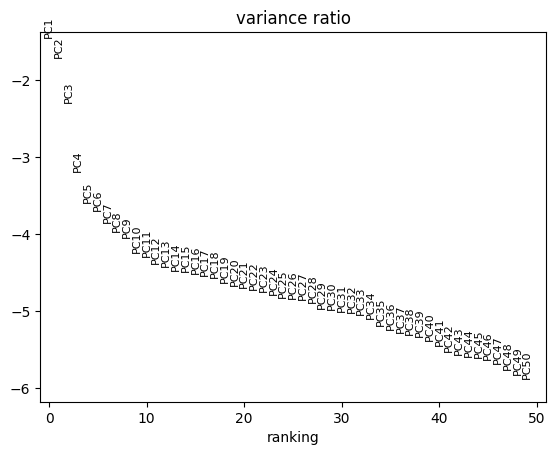

2024-10-25 11:33:50.375946: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-25 11:34:02.952038: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/cray/pe/papi/7.1.0.1/lib64:/opt/cray/libfabric/1.15.2.0/lib64
2024-10-25 11:34:02.952568: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2024-10-25 11:34:24.212467: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dler

In [11]:
# Saving count data
adata_sub.layers["counts"] = adata_sub.X.copy()
# Normalizing to median total counts
sc.pp.normalize_total(adata_sub)
# Logarithmize the data
sc.pp.log1p(adata_sub)
sc.tl.pca(adata_sub)
sc.pl.pca_variance_ratio(adata_sub, n_pcs=50, log=True)
sc.pp.neighbors(adata_sub)


In [14]:
adata_sub.layers["counts"].sum(axis=0)

array([3.3700e+02, 2.3790e+03, 1.0151e+04, 1.0200e+03, 4.0700e+02,
       2.0870e+03, 4.2950e+03, 6.7900e+03, 7.9980e+03, 2.1970e+03,
       6.6000e+02, 1.3050e+03, 6.6900e+02, 3.2500e+02, 5.7490e+03,
       3.2380e+03, 1.7720e+03, 3.2880e+03, 7.7400e+02, 4.3400e+02,
       4.9000e+01, 1.1400e+02, 2.4500e+03, 1.3690e+03, 2.2790e+04,
       2.7218e+04, 3.0340e+04, 9.5000e+02, 6.3600e+03, 1.1453e+04,
       3.6530e+03, 2.5810e+03, 1.4200e+02, 3.7318e+04, 5.1300e+02,
       3.7200e+03, 3.3154e+04, 4.1520e+03, 7.1470e+03, 1.1600e+02,
       1.6000e+01, 1.0300e+03, 5.1300e+02, 3.8444e+04, 6.7440e+03,
       3.2200e+02, 1.2230e+03, 9.4400e+02, 6.0600e+02, 6.3400e+02,
       1.4300e+02, 1.5740e+03, 2.8203e+04, 4.0810e+03, 9.4000e+01,
       7.3540e+03, 8.3940e+03, 3.5300e+03, 2.1086e+04, 7.6820e+03,
       5.7000e+01, 4.3700e+02, 5.0540e+03, 9.1700e+02, 5.4230e+03,
       1.1750e+03, 2.8420e+03, 5.3800e+02, 5.5480e+03, 1.7500e+03,
       1.7516e+04, 6.8120e+03, 2.6593e+04, 2.3400e+02, 4.6540e

In [ ]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
sc.tl.umap(adata_sub)
sc.tl.leiden(adata_sub, n_iterations=2)
# sc.pl.umap(adata_sub, color=["leiden"])

In [12]:
# sc.pl.umap(adata_sub, color=["Annotations"])
import scanpy as sc
import matplotlib.pyplot as plt

# Create the UMAP plot
sc.pl.umap(adata_sub, color=["Annotations"], show=False)  # Use show=False to prevent it from displaying immediately

# Save the plot using Matplotlib
plt.savefig('/scratch/project_465001027/Spatialformer/downstream/subcellular_localization_prediction/Figures/umap_plot.png', dpi=300, bbox_inches='tight')

# Clear the current figure to free memory
plt.clf()

KeyError: "Could not find 'umap' or 'X_umap' in .obsm"

plotting the marker genes


In [49]:
# List of gene markers you want to plot
# gene_markers = epithelial_features[:20] + endothelial_features[:10] + immune_features[:10] + mesenchymal_features[:10]
markers = {"Differentiating Ciliated":["EGFR", "DUOX1", "NKX2-1", "AGR3", "FOXJ1"],
          "B cells": ["BANK1", "CD19", "CD79A", "LTB", "MS4A1"],
          "aCap": ["BMPR2", "CD34", "EPAS1", "GNG11", "PECAM1"],
          "Alveolar FBs": ["SFRP2", "AXL", "COL1A1", "COL1A2", "COL3A1"]}
# Plot the heatmap
sc.pl.heatmap(adata_sub, 
              var_names=markers, 
              groupby='Annotations',
              cmap='viridis', 
              dendrogram=True,  # Adds a dendrogram to show clustering
              show=False)  # Avoid immediate display if you plan to save it

# Save the heatmap if desired
plt.savefig('/scratch/project_465001027/Spatialformer/downstream/subcellular_localization_prediction/Figures/heatmap_plot.png', dpi=300, bbox_inches='tight')

# Clear the current figure if necessary
plt.clf()

<Figure size 720x600 with 0 Axes>

In [38]:
Counter(adata_sub.obs["Annotations"])

Counter({'B cells': 2000,
         'Differentiating Ciliated': 2000,
         'Alveolar FBs': 2000,
         'aCap': 2000})

In [39]:
#export the expression dataframe
adata_sub.write_h5ad("/scratch/project_465001027/Spatialformer/downstream/subcellular_localization_prediction/data/fourcelltypes.h5ad")

running the simulation function

In [122]:

def sim_single_cell(cell_exp, ct, ct_id, gene_list, cell_id):
    '''
    Simulates and plots gene expression pattern localization for a single cell.

    Args:
    - cellmor (any): Indicates morphology or template used for simulation.
    - plot (bool): Whether to plot the simulated localization pattern.
    - cellid (any): Identifier for the cell being simulated.
    - ct (int): An identifier representing the cell type category for classification.
    - cellseed (int): A seed to ensure reproducibility for spot number generation.
    - gene_vocab (list): List of gene identifiers.
    - gene_patterns (list): List of patterns corresponding to each gene.

    Returns:
    - pandas.DataFrame: DataFrame of coordinates and features related to RNA spots simulated in the cell.
    '''
    # import pdb; pdb.set_trace()
#     moridx = cellmor["id"].values[0]
    cellmors = pd.read_csv("/scratch/project_465001027/Spatialformer/downstream/subcellular_localization_prediction/templates/index.csv", sep = ";")
    # cellmors[ct_id]
    ct_mor = cellmors.iloc[ct_id: ct_id+1,]
    pattern_dir = "/scratch/project_465001027/Spatialformer/downstream/subcellular_localization_prediction/templates"
    gene_coords = []
    patterns = ["random", "intranuclear", "extranuclear", "perinuclear", "pericellular"]
    for i, exp in tqdm(enumerate(range(len(cell_exp)))):
        pattern = np.random.choice(patterns)   
        gene_name = gene_list[i]
        instance_coord = simfish.simulate_localization_pattern(pattern_dir, n_spots=exp, index_template=ct_mor, pattern=pattern, proportion_pattern=1)
        rna_coord = instance_coord["rna_coord"]
        coord_df = pd.DataFrame({
        "z": rna_coord[:, 0], 
        "y": rna_coord[:, 1], 
        "x": rna_coord[:, 2], 
        "feature_name": rna_coord.shape[0] * [gene_name], 
        "cell_id": rna_coord.shape[0] * [cell_id],
        "cell_type": rna_coord.shape[0] * [ct],
        "pattern": pattern
        })
        gene_coords.append(coord_df)
    gene_df = pd.concat(gene_coords, ignore_index=True)
    return gene_df



In [94]:
adata_sub.obs

,Annotations,leiden
VUILD107MF_aaaabpgd-1,B cells,2
VUILD107MF_aaaabglg-1,B cells,4
VUILD107MF_aaaalejc-1,B cells,2
VUILD107MF_aaaabgio-1,B cells,2
VUILD107MF_aaaabinf-1,B cells,4
...,...,...
VUHD113_aaaabcbm-1,aCap,1
VUHD113_aaaabcca-1,aCap,1
VUHD113_aaaabfoo-1,Alveolar FBs,3
VUHD113_aaaabfig-1,aCap,1


In [108]:
cell_exp = adata_sub.layers["counts"][cell_idx,:]

In [15]:
adata_sub.layers["counts"][cell_idx,:]

NameError: name 'cell_idx' is not defined

In [109]:
cell_exp

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  3.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  1.,  2.,
        4.,  0.,  0.,  1.,  0.,  1.,  0., 14.,  0.,  0.,  2.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  3.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  1.,  6.,  4.,  0.,  0.,  0.,  0.,  0.,
        0.,  1.,  0.,  0.,  2.,  7.,  1., 18.,  0.,  0.,  0.,  1.],
      dtype=float32)

simulating all the cells

In [19]:
adata_sub.obs_names

Index(['VUILD107MF_aaaabinl-1', 'VUILD107MF_aaaabgfl-1',
       'VUILD107MF_aaaabggd-1', 'VUILD107MF_aaaabpge-1',
       'VUILD107MF_aaaabimf-1', 'VUILD107MF_aaaabimk-1',
       'VUILD107MF_aaaabjee-1', 'VUILD107MF_aaaabgfg-1',
       'VUILD107MF_aaaablbc-1', 'VUILD107MF_aaaabcaf-1',
       ...
       'VUHD113_aaaaamdf-1', 'VUHD113_aaaaalba-1', 'VUHD113_aaaaakhk-1',
       'VUHD113_aaaaamhj-1', 'VUHD113_aaaaaalo-1', 'VUHD113_aaaaakbc-1',
       'VUHD113_aaaabcei-1', 'VUHD113_aaaabcmc-1', 'VUHD113_aaaabckp-1',
       'VUHD113_aaaabfje-1'],
      dtype='object', length=8000)

In [24]:
from multiprocessing import Pool

cell_id = "VUILD107MF_aaaabgfl-1"
cell_idx = list(adata_sub.obs_names).index(cell_id)
cell_types = np.unique(adata_sub.obs["Annotations"])
gene_list = adata_sub.var_names
ct = adata_sub.obs["Annotations"][cell_id]
ct_id = list(cell_types).index(adata_sub.obs["Annotations"][cell_id])
cell_exp = adata_sub.layers["counts"][cell_idx,:]

# gene_df = sim_single_cell(cell_exp, ct, ct_id, gene_list, cell_id)

In [23]:
cell_exp

array([0., 0., 0., 0., 0., 0., 2., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 7., 1., 0., 0., 0., 0., 0., 0.,
       1., 1., 0., 0., 4., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0.], dtype=float32)

In [25]:
cell_exp

array([0., 0., 0., 0., 0., 0., 3., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1.,
       3., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 5., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 8., 0., 0., 0., 0., 0., 0., 0.,
       1., 2., 0., 0., 6., 1., 0., 0., 0., 0., 0., 0., 0., 6., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 2., 0., 0.], dtype=float32)

In [132]:
import concurrent.futures
def process_single_cell(args):
    cell_exp, ct, ct_id, gene_list, cell_id = args
    gene_df = sim_single_cell(cell_exp, ct, ct_id, gene_list, cell_id)
    return gene_df
cell_coord = []
# # import pdb; pdb.set_trace()
# # Use ProcessPoolExecutor for parallel processing
with concurrent.futures.ProcessPoolExecutor() as executor:
    # Preparing arguments to pass to the function
    tasks = [(adata_sub.layers["counts"][cell_idx,:], adata_sub.obs["Annotations"][cell_id], list(cell_types).index(adata_sub.obs["Annotations"][cell_id]), adata_sub.var_names, cell_id) for cell_id in adata_sub.obs_names]

#     # Submit the tasks to the executor
for result in tqdm(executor.map(process_single_cell, tasks), total=cell_num):
    cell_coord.append(result)
cell_df = pd.concat(cell_coord, ignore_index=True)
# cell_df.to_csv("/home/sxr280/Spatialformer/downstream/subcellular_localization_prediction/data/transcripts_genediffpatterns.csv")


RuntimeError: cannot schedule new futures after shutdown

In [133]:
from multiprocessing import Pool


In [ ]:
# Load the AnnData object
adata_sub = sc.read_h5ad("/scratch/project_465001027/Spatialformer/downstream/subcellular_localization_prediction/data/fourcelltypes.h5ad")

def process_single_cell(args):
    cell_exp, ct, ct_id, gene_list, cell_id = args
    gene_df = sim_single_cell(cell_exp, ct, ct_id, gene_list, cell_id)
    return gene_df

# Preparing tasks
tasks = [
    (
        adata_sub.layers["counts"][cell_idx, :],
        adata_sub.obs["Annotations"].iloc[cell_idx],
        list(np.unique(adata_sub.obs["Annotations"])).index(adata_sub.obs["Annotations"].iloc[cell_idx]),
        adata_sub.var_names,
        adata_sub.obs_names[cell_idx]
    )
    for cell_idx in range(len(adata_sub.obs_names))
]

cell_coord = []


# Create a pool of worker processes
with Pool() as pool:  # By default, Pool uses as many processes as there are CPU cores
    for result in tqdm(pool.imap(process_single_cell, tasks), total=len(tasks)):
        cell_coord.append(result)

# Concatenate the results into a DataFrame
cell_df = pd.concat(cell_coord, ignore_index=True)